## Libraries

In [33]:
%pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import requests
import zipfile
import os

# Getting data
from io import StringIO

# Splitting
from sklearn.model_selection import cross_val_score, train_test_split

## Functions

### Get Data

In [2]:
def get_data():

    dfResult = None

    # Download German Credit Data from UCI ML Repository
    url = "https://archive.ics.uci.edu/static/public/144/statlog+german+credit+data.zip"

    # Download the zip file
    response = requests.get(url)
    response.raise_for_status()

    # Extract the zip file and load data into DataFrame
    from io import BytesIO
    with zipfile.ZipFile(BytesIO(response.content)) as zip_file:
        # List files in the zip
        file_list = zip_file.namelist()
        print("Files in the dataset:")
        for file in file_list:
            print(f"  {file}")
        
        # Find the main data file (usually german.data)
        data_file = None
        for file in file_list:
            if file.endswith('.data') or 'german' in file.lower():
                data_file = file
                break
        
        if data_file:
            with zip_file.open(data_file) as f:
                # Read the data file
                data_content = f.read().decode('utf-8')
                
                # Load into pandas DataFrame
                # German credit data is space-separated
                dfResult = pd.read_csv(StringIO(data_content), sep=' ', header=None)
                
                print(f"\nDataset loaded successfully!")
        else:
            print("Could not find the main data file in the zip archive")
        
    return dfResult


### Data cleaning

In [3]:
def add_column_names(df):
    """
    Adds proper column names to the dataframe
    
    Args:
        df (pd.DataFrame): The dataframe to add column names to
    
    Returns:
        pd.DataFrame: Dataframe with proper column names
    """
    column_names = [
        'checking_account_status',    # Attribute 1
        'duration_months',            # Attribute 2
        'credit_history',            # Attribute 3
        'purpose',                   # Attribute 4
        'credit_amount',             # Attribute 5
        'savings_account',           # Attribute 6
        'employment_since',          # Attribute 7
        'installment_rate',          # Attribute 8
        'personal_status_sex',       # Attribute 9
        'other_debtors',             # Attribute 10
        'residence_since',           # Attribute 11
        'property',                  # Attribute 12
        'age_years',                 # Attribute 13
        'other_installment_plans',   # Attribute 14
        'housing',                   # Attribute 15
        'existing_credits',          # Attribute 16
        'job',                       # Attribute 17
        'num_dependents',            # Attribute 18
        'telephone',                 # Attribute 19
        'foreign_worker',            # Attribute 20
        'class'                      # Target variable (1=good, 2=bad)
    ]
    
    df_named = df.copy()
    df_named.columns = column_names
    
    return df_named



In [4]:
def get_feature_mappings():
    """Returns a dictionary containing all feature mappings"""
    
    mappings = {
        # Attribute 1: Status of existing checking account
        0: {
            'A11': '< 0 DM',
            'A12': '0 <= ... < 200 DM', 
            'A13': '>= 200 DM / salary assignments for at least 1 year',
            'A14': 'no checking account'
        },
        
        # Attribute 3: Credit history
        2: {
            'A30': 'no credits taken / all credits paid back duly',
            'A31': 'all credits at this bank paid back duly',
            'A32': 'existing credits paid back duly till now',
            'A33': 'delay in paying off in the past',
            'A34': 'critical account / other credits existing (not at this bank)'
        },
        
        # Attribute 4: Purpose
        3: {
            'A40': 'car (new)',
            'A41': 'car (used)',
            'A42': 'furniture/equipment',
            'A43': 'radio/television',
            'A44': 'domestic appliances',
            'A45': 'repairs',
            'A46': 'education',
            'A48': 'retraining',
            'A49': 'business',
            'A410': 'others'
        },
        
        # Attribute 6: Savings account/bonds
        5: {
            'A61': '< 100 DM',
            'A62': '100 <= ... < 500 DM',
            'A63': '500 <= ... < 1000 DM',
            'A64': '>= 1000 DM',
            'A65': 'unknown / no savings account'
        },
        
        # Attribute 7: Present employment since
        6: {
            'A71': 'unemployed',
            'A72': '< 1 year',
            'A73': '1 <= ... < 4 years',
            'A74': '4 <= ... < 7 years',
            'A75': '>= 7 years'
        },
        
        # Attribute 9: Personal status and sex
        8: {
            'A91': 'male : divorced/separated',
            'A92': 'female : divorced/separated/married',
            'A93': 'male : single',
            'A94': 'male : married/widowed',
            'A95': 'female : single'
        },
        
        # Attribute 10: Other debtors / guarantors
        9: {
            'A101': 'none',
            'A102': 'co-applicant',
            'A103': 'guarantor'
        },
        
        # Attribute 12: Property
        11: {
            'A121': 'real estate',
            'A122': 'building society savings agreement / life insurance',
            'A123': 'car or other, not in attribute 6',
            'A124': 'unknown / no property'
        },
        
        # Attribute 14: Other installment plans
        13: {
            'A141': 'bank',
            'A142': 'stores',
            'A143': 'none'
        },
        
        # Attribute 15: Housing
        14: {
            'A151': 'rent',
            'A152': 'own',
            'A153': 'for free'
        },
        
        # Attribute 17: Job
        16: {
            'A171': 'unemployed / unskilled - non-resident',
            'A172': 'unskilled - resident',
            'A173': 'skilled employee / official',
            'A174': 'management / self-employed / highly qualified employee / officer'
        },
        
        # Attribute 19: Telephone
        18: {
            'A191': 'none',
            'A192': 'yes, registered under the customers name'
        },
        
        # Attribute 20: Foreign worker
        19: {
            'A201': 'yes',
            'A202': 'no'
        }
    }
    
    return mappings

In [5]:
def transform_dataframe_with_labels(df):
    """
    Transforms the entire dataframe by replacing categorical codes with actual meanings
    
    Args:
        df (pd.DataFrame): The original dataframe with categorical codes
    
    Returns:
        pd.DataFrame: A new dataframe with readable labels
    """
    # Create a copy of the dataframe
    df_transformed = df.copy()
    
    # Get the mappings
    mappings = get_feature_mappings()
    
    # Apply mappings to categorical columns
    for column_index, mapping_dict in mappings.items():
        if column_index < len(df.columns):
            df_transformed.iloc[:, column_index] = df_transformed.iloc[:, column_index].map(mapping_dict).fillna(df_transformed.iloc[:, column_index])
    
    return df_transformed

## Extracting Data & Cleaning

First we download the dataset from the URL https://archive.ics.uci.edu/static/public/144/statlog+german+credit+data.zip

In [10]:

df_credit = get_data()
df_credit.head()

Files in the dataset:
  german.data
  german.data-numeric
  german.doc
  Index

Dataset loaded successfully!


,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


Now we clean the data. We add the column names and the real values of the categorical features.

In [11]:
df_credit = add_column_names(df_credit)

# Adding real values to the dataframe
# df_credit = transform_dataframe_with_labels(df_credit)
df_credit.head(10)

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age_years,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2
5,A14,36,A32,A46,9055,A65,A73,2,A93,A101,...,A124,35,A143,A153,1,A172,2,A192,A201,1
6,A14,24,A32,A42,2835,A63,A75,3,A93,A101,...,A122,53,A143,A152,1,A173,1,A191,A201,1
7,A12,36,A32,A41,6948,A61,A73,2,A93,A101,...,A123,35,A143,A151,1,A174,1,A192,A201,1
8,A14,12,A32,A43,3059,A64,A74,2,A91,A101,...,A121,61,A143,A152,1,A172,1,A191,A201,1
9,A12,30,A34,A40,5234,A61,A71,4,A94,A101,...,A123,28,A143,A152,2,A174,1,A191,A201,2


In [13]:
df_credit.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   checking_account_status  1000 non-null   str  
 1   duration_months          1000 non-null   int64
 2   credit_history           1000 non-null   str  
 3   purpose                  1000 non-null   str  
 4   credit_amount            1000 non-null   int64
 5   savings_account          1000 non-null   str  
 6   employment_since         1000 non-null   str  
 7   installment_rate         1000 non-null   int64
 8   personal_status_sex      1000 non-null   str  
 9   other_debtors            1000 non-null   str  
 10  residence_since          1000 non-null   int64
 11  property                 1000 non-null   str  
 12  age_years                1000 non-null   int64
 13  other_installment_plans  1000 non-null   str  
 14  housing                  1000 non-null   str  
 15  existing_credits

In [14]:
# Assuming 'df' is your DataFrame
print(df_credit.isnull().sum())

checking_account_status    0
duration_months            0
credit_history             0
purpose                    0
credit_amount              0
savings_account            0
employment_since           0
installment_rate           0
personal_status_sex        0
other_debtors              0
residence_since            0
property                   0
age_years                  0
other_installment_plans    0
housing                    0
existing_credits           0
job                        0
num_dependents             0
telephone                  0
foreign_worker             0
class                      0
dtype: int64


## Splitting into Training, Test and Validation

In [15]:
df_train_val, df_test = train_test_split(df_credit, test_size=0.15, random_state=1505)

# Validation set (15% of total data) -> 0.15 / (1 - 0.15) ≈ 0.176
df_train, df_val = train_test_split(df_train_val, test_size=0.176, random_state=1505)

# Print the sizes of the datasets
print(f"Training set size: {len(df_train)}")
print(f"Validation set size: {len(df_val)}")
print(f"Test set size: {len(df_test)}")


# Prepare Training Sets
X_train = df_train.drop(columns=['class'])
y_train = df_train['class']

# Prepare Validation Sets
X_val = df_val.drop(columns=['class'])
y_val = df_val['class']

# Prepare Test Sets
X_test = df_test.drop(columns=['class'])
y_test = df_test['class']

Training set size: 700
Validation set size: 150
Test set size: 150


In [16]:
counts = X_train['checking_account_status'].value_counts()

print(counts)

checking_account_status
A14    274
A11    195
A12    190
A13     41
Name: count, dtype: int64


## Model Pipeline

First we create a pipeline that transform the data before training the model

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Defining type of features
ordinal_features = ['checking_account_status', 'savings_account', 'employment_since']

categorical_features = ['credit_history', 'purpose', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']

numerical_features = ['duration_months', 'credit_amount', 'installment_rate', 'residence_since', 'age_years', 'existing_credits', 'num_dependents']

# Defining order of ordinal features
# 'A11': '< 0 DM',
# 'A12': '0 <= ... < 200 DM', 
# 'A13': '>= 200 DM / salary assignments for at least 1 year',
# 'A14': 'no checking account'
checking_account_status_order = ['A11', 'A14', 'A12', 'A13']

# 'A61': '< 100 DM',
# 'A62': '100 <= ... < 500 DM',
# 'A63': '500 <= ... < 1000 DM',
# 'A64': '>= 1000 DM',
# 'A65': 'unknown / no savings account'
savings_account_order = ['A65', 'A61', 'A62', 'A63', 'A64']

# 'A71': 'unemployed',
# 'A72': '< 1 year',
# 'A73': '1 <= ... < 4 years',
# 'A74': '4 <= ... < 7 years',
# 'A75': '>= 7 years'
employment_since_order = ['A71', 'A72', 'A73', 'A74', 'A75']


# Defining Ord Encoder
ord_encoder = OrdinalEncoder(
    categories=[checking_account_status_order, savings_account_order, employment_since_order],
    handle_unknown='use_encoded_value',
    unknown_value=-1
    )

pipe_ordinal = Pipeline(steps=[
    ('encoder', ord_encoder)
])

pipe_categorical = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

pipe_numerical = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    # ('scaler', StandardScaler()) We don't need it since we are going to create a Random Forest and XGBoost model
])

preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal', pipe_ordinal, ordinal_features),
        ('categorical', pipe_categorical, categorical_features),
        ('numerical', pipe_numerical, numerical_features)
    ],
    remainder='drop'
)

preprocessor.set_output(transform='pandas')
df_train_preprocessed = preprocessor.fit_transform(X_train)
df_val_preprocessed = preprocessor.transform(X_val)
df_test_preprocessed = preprocessor.transform(X_test)
df_train_preprocessed.head(5)

,ordinal__checking_account_status,ordinal__savings_account,ordinal__employment_since,categorical__credit_history_A30,categorical__credit_history_A31,categorical__credit_history_A32,categorical__credit_history_A33,categorical__credit_history_A34,categorical__purpose_A40,categorical__purpose_A41,...,categorical__telephone_A192,categorical__foreign_worker_A201,categorical__foreign_worker_A202,numerical__duration_months,numerical__credit_amount,numerical__installment_rate,numerical__residence_since,numerical__age_years,numerical__existing_credits,numerical__num_dependents
797,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,12.0,1258.0,2.0,4.0,22.0,2.0,1.0
832,0.0,1.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,45.0,11816.0,2.0,4.0,29.0,2.0,1.0
358,1.0,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,12.0,776.0,4.0,2.0,28.0,1.0,1.0
572,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,1.0,0.0,24.0,5433.0,2.0,4.0,26.0,1.0,1.0
896,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,21.0,2606.0,4.0,4.0,28.0,1.0,1.0


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)

print(f"Class labels: {le.classes_}")
print(f"Training set labels: {set(y_train)}")

Class labels: [1 2]
Training set labels: {np.int64(0), np.int64(1)}


## Model Training

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=1505),
    "Random Forest": RandomForestClassifier(random_state=1505, n_estimators=100),
    "XGBoost": XGBClassifier(
        random_state=1505, 
        objective='binary:logistic',
        eval_metric='logloss' # Removes warning messages
    )
}

# Dictionary to save trained models for later use
trained_models = {}

# 3. Loop: Train -> Predict -> Evaluate
print(f"{'Model':<15} | {'Val Accuracy':<12}")
print("-" * 30)

for name, model in models.items():
    # Train (Fit) on the preprocessed training data
    model.fit(df_train_preprocessed, y_train)
    
    # Predict on the preprocessed validation data
    y_pred_val = model.predict(df_val_preprocessed)
    
    # Score
    acc = accuracy_score(y_val, y_pred_val)
    print(f"{name:<15} | {acc:.4f}")
    
    # Save the trained model
    trained_models[name] = model

print("-" * 30)

Model           | Val Accuracy
------------------------------
Decision Tree   | 0.7200
Random Forest   | 0.7867
XGBoost         | 0.7933
------------------------------


## Performance Comparison

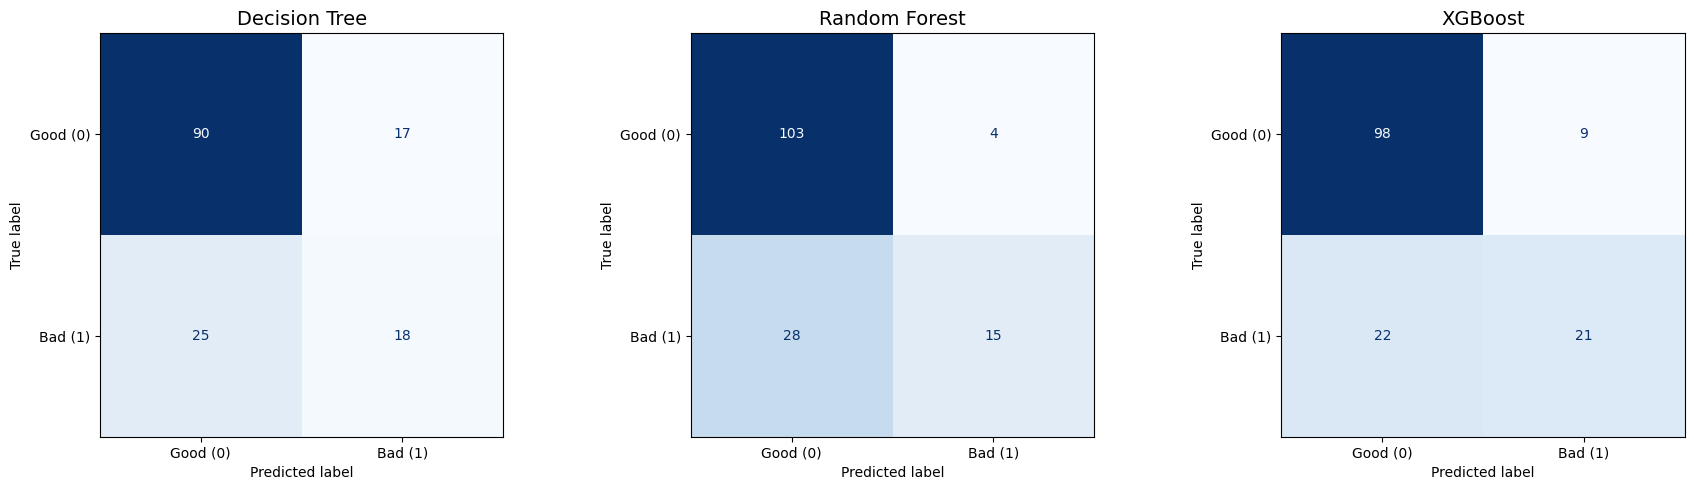

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score
)

# Setup the figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) 

# Iterate through models and assign each to a specific axis (subplot)
for i, (name, model) in enumerate(trained_models.items()):
    
    ax = axes[i] # Get the specific subplot for this model
    
    # Predict
    y_pred = model.predict(df_val_preprocessed)
    
    # Plot Confusion Matrix on the specific axis 'ax'
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good (0)', 'Bad (1)'])
    disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False) 
    
    ax.set_title(f'{name}', fontsize=14)

plt.tight_layout()
plt.show()

In [40]:
from sklearn.metrics import classification_report

for name, model in trained_models.items():
    print(f"========== {name} ==========")
    y_pred = model.predict(df_val_preprocessed)
    
    # Printing the classification report
    print(classification_report(y_val, y_pred, target_names=['Good Credit (0)', 'Bad Credit (1)']))
    print("\n")

========== Decision Tree ==========
                 precision    recall  f1-score   support

Good Credit (0)       0.78      0.84      0.81       107
 Bad Credit (1)       0.51      0.42      0.46        43

       accuracy                           0.72       150
      macro avg       0.65      0.63      0.64       150
   weighted avg       0.71      0.72      0.71       150



========== Random Forest ==========
                 precision    recall  f1-score   support

Good Credit (0)       0.79      0.96      0.87       107
 Bad Credit (1)       0.79      0.35      0.48        43

       accuracy                           0.79       150
      macro avg       0.79      0.66      0.67       150
   weighted avg       0.79      0.79      0.76       150



========== XGBoost ==========
                 precision    recall  f1-score   support

Good Credit (0)       0.82      0.92      0.86       107
 Bad Credit (1)       0.70      0.49      0.58        43

       accuracy                

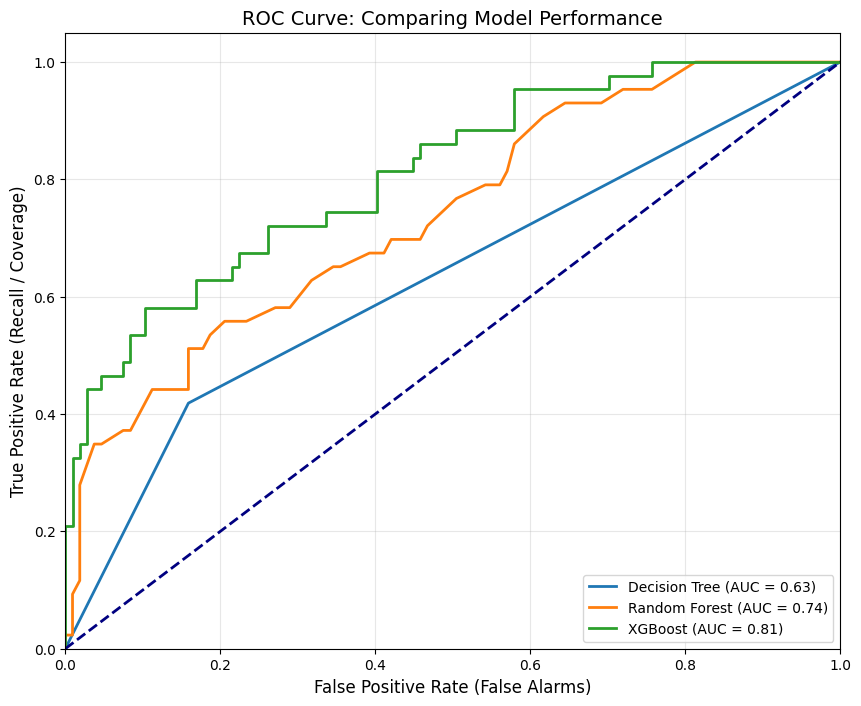

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Loop through our trained models
for name, model in trained_models.items():
    # 1. Get the probability of the Positive Class (1 = Bad Credit)
    # predict_proba returns [prob_0, prob_1], we want index 1
    y_probs = model.predict_proba(df_val_preprocessed)[:, 1]
    
    # Calculate the curve coordinates
    fpr, tpr, thresholds = roc_curve(y_val, y_probs, pos_label=1)
    
    # Calculate the Area Under the Curve (AUC) score
    roc_auc = auc(fpr, tpr)
    
    # 4. Plot
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

# Plot the "Random Guess" line (50/50 coin flip)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Labels and Title
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)', fontsize=12)
plt.ylabel('True Positive Rate (Recall / Coverage)', fontsize=12)
plt.title('ROC Curve: Comparing Model Performance', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()